# Task 1 — Basic EDA: Understanding the DSE Dataset

Before diving into complex analysis, we need to understand what the data looks like, its quality, and the market's basic characteristics. This section lays the groundwork.

**Key question answered here:** What does the DSE market look like at a high level?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROCESSED = '../data/processed/'

In [2]:
prices = pd.read_parquet(PROCESSED + 'prices.parquet')
volume = pd.read_parquet(PROCESSED + 'volume.parquet')
returns = pd.read_parquet(PROCESSED + 'returns.parquet')
sector_returns = pd.read_parquet(PROCESSED + 'sector_returns.parquet')
sector_map = pd.read_csv(PROCESSED + 'sector_map.csv', index_col=0).squeeze()

In [5]:
prices.head(2)

Ticker,BENGALBISC,KFL,WONDERTOYS,UNIONINS,MASTERAGRO,ORYZAAGRO,MOSTFAMETL,MONNOFABR,APEXWEAV,BPPL,...,UTTARABANK,BDCOM,JAMUNAOIL,PUBALIBANK,PRIMEBANK,EHL,SQURPHARMA,OLYMPIC,KEYACOSMET,BDWELDING
Date,,,,,,,,,,,,,,,,,,,,,
2012-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.254145,15.245658,171.7737,19.892148,27.816940,58.1818,73.99,45.5418,20.693030,31.3333
2012-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.656600,16.573667,176.1602,20.073517,27.978271,57.4545,73.82,46.2003,20.604545,31.1429


In [6]:
volume.head(2)

Ticker,BENGALBISC,KFL,WONDERTOYS,UNIONINS,MASTERAGRO,ORYZAAGRO,MOSTFAMETL,MONNOFABR,APEXWEAV,BPPL,...,UTTARABANK,BDCOM,JAMUNAOIL,PUBALIBANK,PRIMEBANK,EHL,SQURPHARMA,OLYMPIC,KEYACOSMET,BDWELDING
Date,,,,,,,,,,,,,,,,,,,,,
2012-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,450574.0,1395735.0,504461.0,991980.0,573925.0,726660.0,520196.0,2837633.0,5729476.0,684075.0
2012-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,538934.0,1224520.0,1000428.0,1498959.0,1014475.0,935303.0,979474.0,4270118.0,7429986.0,788550.0


In [7]:
returns.head(2)

Ticker,BENGALBISC,KFL,WONDERTOYS,UNIONINS,MASTERAGRO,ORYZAAGRO,MOSTFAMETL,MONNOFABR,APEXWEAV,BPPL,...,UTTARABANK,BDCOM,JAMUNAOIL,PUBALIBANK,PRIMEBANK,EHL,SQURPHARMA,OLYMPIC,KEYACOSMET,BDWELDING
Date,,,,,,,,,,,,,,,,,,,,,
2012-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.028234,0.087107,0.025537,0.009118,0.005800,-0.012500,-0.002298,0.014459,-0.004276,-0.006077
2012-10-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.020595,-0.009614,0.043448,-0.003013,-0.005766,-0.023909,-0.003928,-0.019597,-0.030043,-0.042816


In [8]:
sector_returns.head(2)

,Bank,Cement,Ceramics,Engineering,Food & Allied,Fuel & Power,IT,Insurance,Jute,Mutual Funds,NBFI,Paper & Printing,Pharmaceuticals,Services & Real Estate,Tannery,Telecom,Textile,Travel & Leisure
Date,,,,,,,,,,,,,,,,,,
2012-10-02,0.049147,-0.001341,-0.002479,0.008672,0.011903,0.022132,0.051416,0.030620,0.011944,0.066384,0.025947,-0.022521,0.017087,0.001224,0.030403,-0.000597,-0.012602,0.030217
2012-10-03,-0.023402,-0.001445,-0.017326,-0.023661,-0.015731,0.008695,-0.045682,0.006528,-0.051633,-0.010580,-0.020333,-0.012518,-0.024221,-0.016223,0.010060,0.005977,-0.024755,-0.040314


In [9]:
sector_map.head(2)

BENGALBISC    Food & Allied
KFL             Engineering
Name: sector, dtype: str

## 1.1 Dataset Overview

In [10]:
print("=== DSE Dataset Summary ===")
print(f"Date range     : {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Trading years  : {(prices.index.max() - prices.index.min()).days / 365:.1f} years")
print(f"Total trading days: {len(prices)}")
print(f"Unique stocks  : {prices.shape[1]}")
print(f"Sectors covered: {sector_returns.shape[1]}")

# DSE trades Sunday-Thursday (not Mon-Fri like western markets)
day_counts = prices.index.day_name().value_counts()
print(f"\nTrading days per weekday (confirms DSE Sunday-Thursday schedule):")
print(day_counts)

=== DSE Dataset Summary ===
Date range     : 2012-10-01 to 2026-01-22
Trading years  : 13.3 years
Total trading days: 3173
Unique stocks  : 386
Sectors covered: 18

Trading days per weekday (confirms DSE Sunday-Thursday schedule):
Date
Monday       641
Thursday     639
Tuesday      635
Wednesday    632
Sunday       622
Saturday       4
Name: count, dtype: int64


## 1.2 DSEX Index Price History

We construct a market-cap proxy index by averaging the top liquid stocks. If the dataset includes a DSEX index column directly, use that.

DSEX loaded: 3172 trading days
Date range: 2012-10-01 to 2026-01-22
Index range: 3439 to 7368


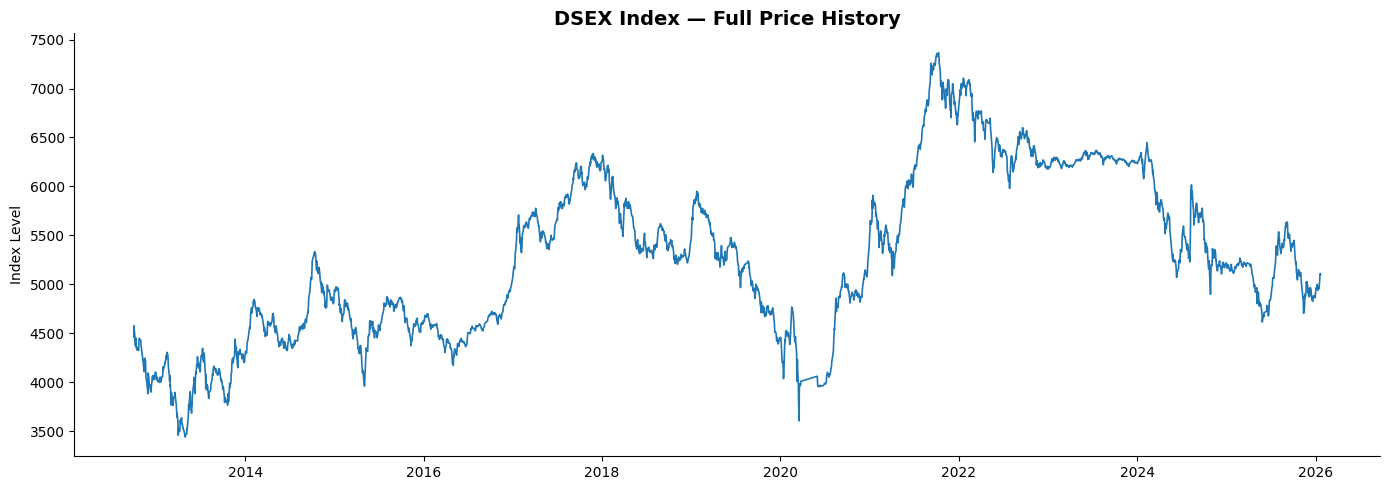


All-time high: 2021-10-10 — Level: 7368
All-time low : 2013-04-30 — Level: 3439


In [12]:
# # If there's a 'DSEX' or 'INDEX' column in prices, use it. Otherwise build a proxy.
# index_candidates = [c for c in prices.columns if 'DSEX' in c.upper() or 'INDEX' in c.upper()]

# if index_candidates:
#     market_price = prices[index_candidates[0]]
#     market_label = index_candidates[0]
# else:
#     # Build a broad market proxy: equal-weight top 50 most liquid stocks
#     avg_volume = volume.mean().nlargest(50).index
#     market_price = prices[avg_volume].mean(axis=1)
#     market_price = market_price / market_price.iloc[0] * 1000  # rebase to 1000
#     market_label = 'Market Proxy (Top 50 Stocks, Equal-Weighted)'

# fig, ax = plt.subplots(figsize=(14, 5))
# ax.plot(market_price.index, market_price.values, color='#1f77b4', linewidth=1.2)
# ax.set_title('DSE Market — Historical Price Level', fontsize=14, fontweight='bold')
# ax.set_xlabel('')
# ax.set_ylabel('Index Level')
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# plt.tight_layout()
# plt.show()

# # Mark notable periods
# print("\nAll-time high:", market_price.idxmax().date(), f"— Level: {market_price.max():.0f}")
# print("All-time low :", market_price.idxmin().date(), f"— Level: {market_price.min():.0f}")

RAW_DIR = '../data/raw/Dhaka Stock Exchange End-of-Day Financial Dataset/Company Separated Adjusted Data/'

# Load DSEX directly — the most accurate market benchmark
dsex = pd.read_csv(RAW_DIR + '00DSEX.csv', parse_dates=['Date'])
dsex.columns = [c.lower() for c in dsex.columns]
dsex = dsex.sort_values('date').set_index('date')

market_price = dsex['close']
market_label = 'DSEX (Dhaka Stock Exchange Broad Index)'

print(f"DSEX loaded: {len(market_price)} trading days")
print(f"Date range: {market_price.index.min().date()} to {market_price.index.max().date()}")
print(f"Index range: {market_price.min():.0f} to {market_price.max():.0f}")

# Calculate daily returns from DSEX
# market_returns = market_price.pct_change().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(market_price.index, market_price.values, color='#1f77b4', linewidth=1.2)
ax.set_title('DSEX Index — Full Price History', fontsize=14, fontweight='bold')
ax.set_ylabel('Index Level')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print(f"\nAll-time high: {market_price.idxmax().date()} — Level: {market_price.max():.0f}")
print(f"All-time low : {market_price.idxmin().date()} — Level: {market_price.min():.0f}")


## 1.3 Return Distribution — Are DSE Returns Normal?

This matters because most risk models assume normally distributed returns. DSE's retail-heavy market often shows fat tails (extreme moves happen more often than a normal distribution would predict).

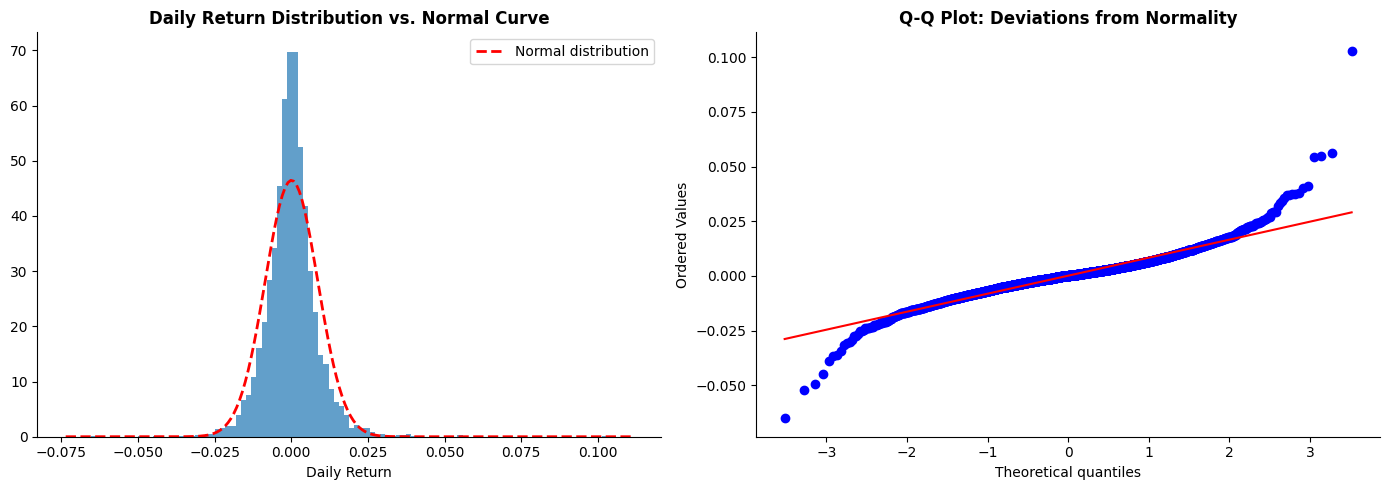

Skewness : 0.659  (0 = symmetric; negative = left tail)
Kurtosis : 11.486  (0 = normal; positive = fat tails)
Jarque-Bera p-value: 0.0000

Insight: DSE returns are NOT normally distributed (p < 0.05).
Fat tails mean extreme losses happen more often than standard risk models expect.
Implication: VaR and CVaR should use historical simulation, not the normal distribution.


In [13]:
from scipy import stats

market_returns = market_price.pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(market_returns, bins=100, color='#1f77b4', alpha=0.7, density=True)
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 200)
normal_pdf = stats.norm.pdf(x, market_returns.mean(), market_returns.std())
axes[0].plot(x, normal_pdf, 'r--', linewidth=2, label='Normal distribution')
axes[0].set_title('Daily Return Distribution vs. Normal Curve', fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].legend()

# Q-Q plot
stats.probplot(market_returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Deviations from Normality', fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical tests
_, jb_p = stats.jarque_bera(market_returns)
skew = market_returns.skew()
kurt = market_returns.kurtosis()

print(f"Skewness : {skew:.3f}  (0 = symmetric; negative = left tail)")
print(f"Kurtosis : {kurt:.3f}  (0 = normal; positive = fat tails)")
print(f"Jarque-Bera p-value: {jb_p:.4f}")
print()
if jb_p < 0.05:
    print("Insight: DSE returns are NOT normally distributed (p < 0.05).")
    print("Fat tails mean extreme losses happen more often than standard risk models expect.")
    print("Implication: VaR and CVaR should use historical simulation, not the normal distribution.")

## 1.4 Summary Statistics by Sector

In [14]:
RISK_FREE_RATE = 0.075 / 252  # Bangladesh T-bill rate ~7.5% annualized

stats_rows = []
for sector in sector_returns.columns:
    s = sector_returns[sector].dropna()
    ann_return = s.mean() * 252
    ann_vol = s.std() * np.sqrt(252)
    sharpe = (s.mean() - RISK_FREE_RATE) / s.std() * np.sqrt(252)
    skewness = s.skew()
    excess_kurt = s.kurtosis()

    # Max drawdown
    cum = (1 + s).cumprod()
    rolling_max = cum.cummax()
    drawdown = (cum - rolling_max) / rolling_max
    max_dd = drawdown.min()

    stats_rows.append({
        'Sector': sector,
        'Ann. Return': f"{ann_return:.1%}",
        'Ann. Volatility': f"{ann_vol:.1%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd:.1%}",
        'Skewness': f"{skewness:.2f}",
        'Kurtosis': f"{excess_kurt:.2f}",
    })

sector_stats = pd.DataFrame(stats_rows).set_index('Sector')
print("Sector Performance Summary (Full History):")
display(sector_stats)

Sector Performance Summary (Full History):


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Skewness,Kurtosis
Sector,,,,,,
Bank,3.2%,17.8%,-0.24,-43.9%,0.99,3.42
Cement,0.6%,22.0%,-0.31,-54.6%,0.71,3.00
Ceramics,11.9%,26.7%,0.17,-58.8%,0.35,1.35
Engineering,10.8%,19.0%,0.17,-40.0%,0.21,3.07
Food & Allied,17.6%,18.5%,0.54,-33.8%,0.05,2.51
Fuel & Power,2.3%,17.8%,-0.29,-49.9%,0.43,2.93
IT,7.5%,27.7%,0.00,-54.6%,0.53,1.48
Insurance,11.7%,25.7%,0.16,-54.9%,0.76,2.39
Jute,16.2%,33.7%,0.26,-66.1%,0.41,1.11


##### Annual Return — "How much did this sector earn per year on average?"
* Bangladesh's risk-free T-bill rate is 7.5%. So any sector below 7.5% annual return actually underperformed just holding government bonds. That means Bank (3.2%), Cement (0.6%), Fuel & Power (2.3%), NBFI (-1.9%), Mutual Funds (1.2%) all failed to justify their risk.

##### Annual Volatility — "How violently did returns swing up and down each year?"
* You want high return + low volatility. Food & Allied gives you 17.6% return with only 18.5% volatility. NBFI gives -1.9% return with 27% volatility — that is the worst possible combination.

##### Sharpe Ratio — "Was the risk worth taking?"
` Sharpe = (Sector Return − Risk-Free Rate) / Volatility
       = (What you earned − What you could earn risk-free) / How much you suffered `

Sharpe > 1.0 = excellent
Sharpe 0.5–1.0 = good
Sharpe 0–0.5 = acceptable
Sharpe < 0 = you should have kept money in the bank — literally
* Our analysis shows Food & Allied and Paper & Printing are the only sectors on DSE that have consistently rewarded risk over 13 years. Banking, despite dominating the DSEX index, shows negative risk-adjusted returns. This is a structural problem in the sector worth investigating.

##### Max Drawdown — "What was the absolute worst-case loss?"
* The gut-check question: Would your client stay invested if their portfolio fell 79.7%? Almost nobody would — they would panic-sell, locking in the loss permanently. This is why drawdown matters more than average return for retail investors.

* NBFI (-79.7% drawdown) is a sector where margin calls are near-certain during a crash. IDLC should charge higher margins or restrict lending against NBFI stocks.

##### Skewness — "Does the sector have a lopsided return distribution?"
- Skewness measures whether big gains or big losses are more common.

* Positive skewness = rare large gains, frequent small losses (lottery-like)
* Negative skewness = rare large losses, frequent small gains (insurance-like, bad for investors)
* Zero = symmetric

###### Kurtosis — "How often do extreme events happen?"
- Kurtosis measures the "fatness" of the tails — how often very large moves (in either direction) occur.

* Kurtosis = 0 → normal distribution (textbook bell curve)
* Kurtosis > 0 → fat tails → extreme events happen MORE than a normal model predicts
* Kurtosis < 0 → thin tails → returns are more clustered around the 

---

### Key Findings — Sector Performance Summary (2012–2026)

| What the metric asks | Best sector | Worst sector |
|---|---|---|
| Who earned the most? (Ann. Return) | Paper & Printing +21.2% | NBFI -1.9% |
| Who was most stable? (Volatility) | Pharmaceuticals 17.2% | Jute 33.7% |
| Was risk worth it? (Sharpe Ratio) | Food & Allied +0.54 | NBFI -0.35 |
| Worst crisis moment? (Max Drawdown) | Food & Allied -33.8% | NBFI -79.7% |
| Extreme tail events? (Kurtosis) | Travel & Leisure 1.01 | Mutual Funds 5.51 |

**Investment Insight:** Food & Allied is the standout sector on DSE — highest Sharpe ratio (0.54),
lowest drawdown (-33.8%), and strong annual return (17.6%). It is the only DSE sector that
consistently rewarded investors relative to risk over the full 13-year period.

Banking, despite being the largest component of the DSEX index, shows negative risk-adjusted
returns (Sharpe: -0.24, Ann. Return: 3.2% vs. 7.5% risk-free rate). Sector dominance in the
index does not imply investor value — this is a key distinction for active portfolio management.

NBFI is the weakest sector on every dimension: negative annual return (-1.9%), highest drawdown
(-79.7%), and worst Sharpe ratio (-0.35). For margin financing purposes, NBFI stocks carry the
highest risk of margin calls during market stress.


## 1.5 Missing Data Heatmap

Understanding data gaps helps us know which stocks we can trust for analysis.

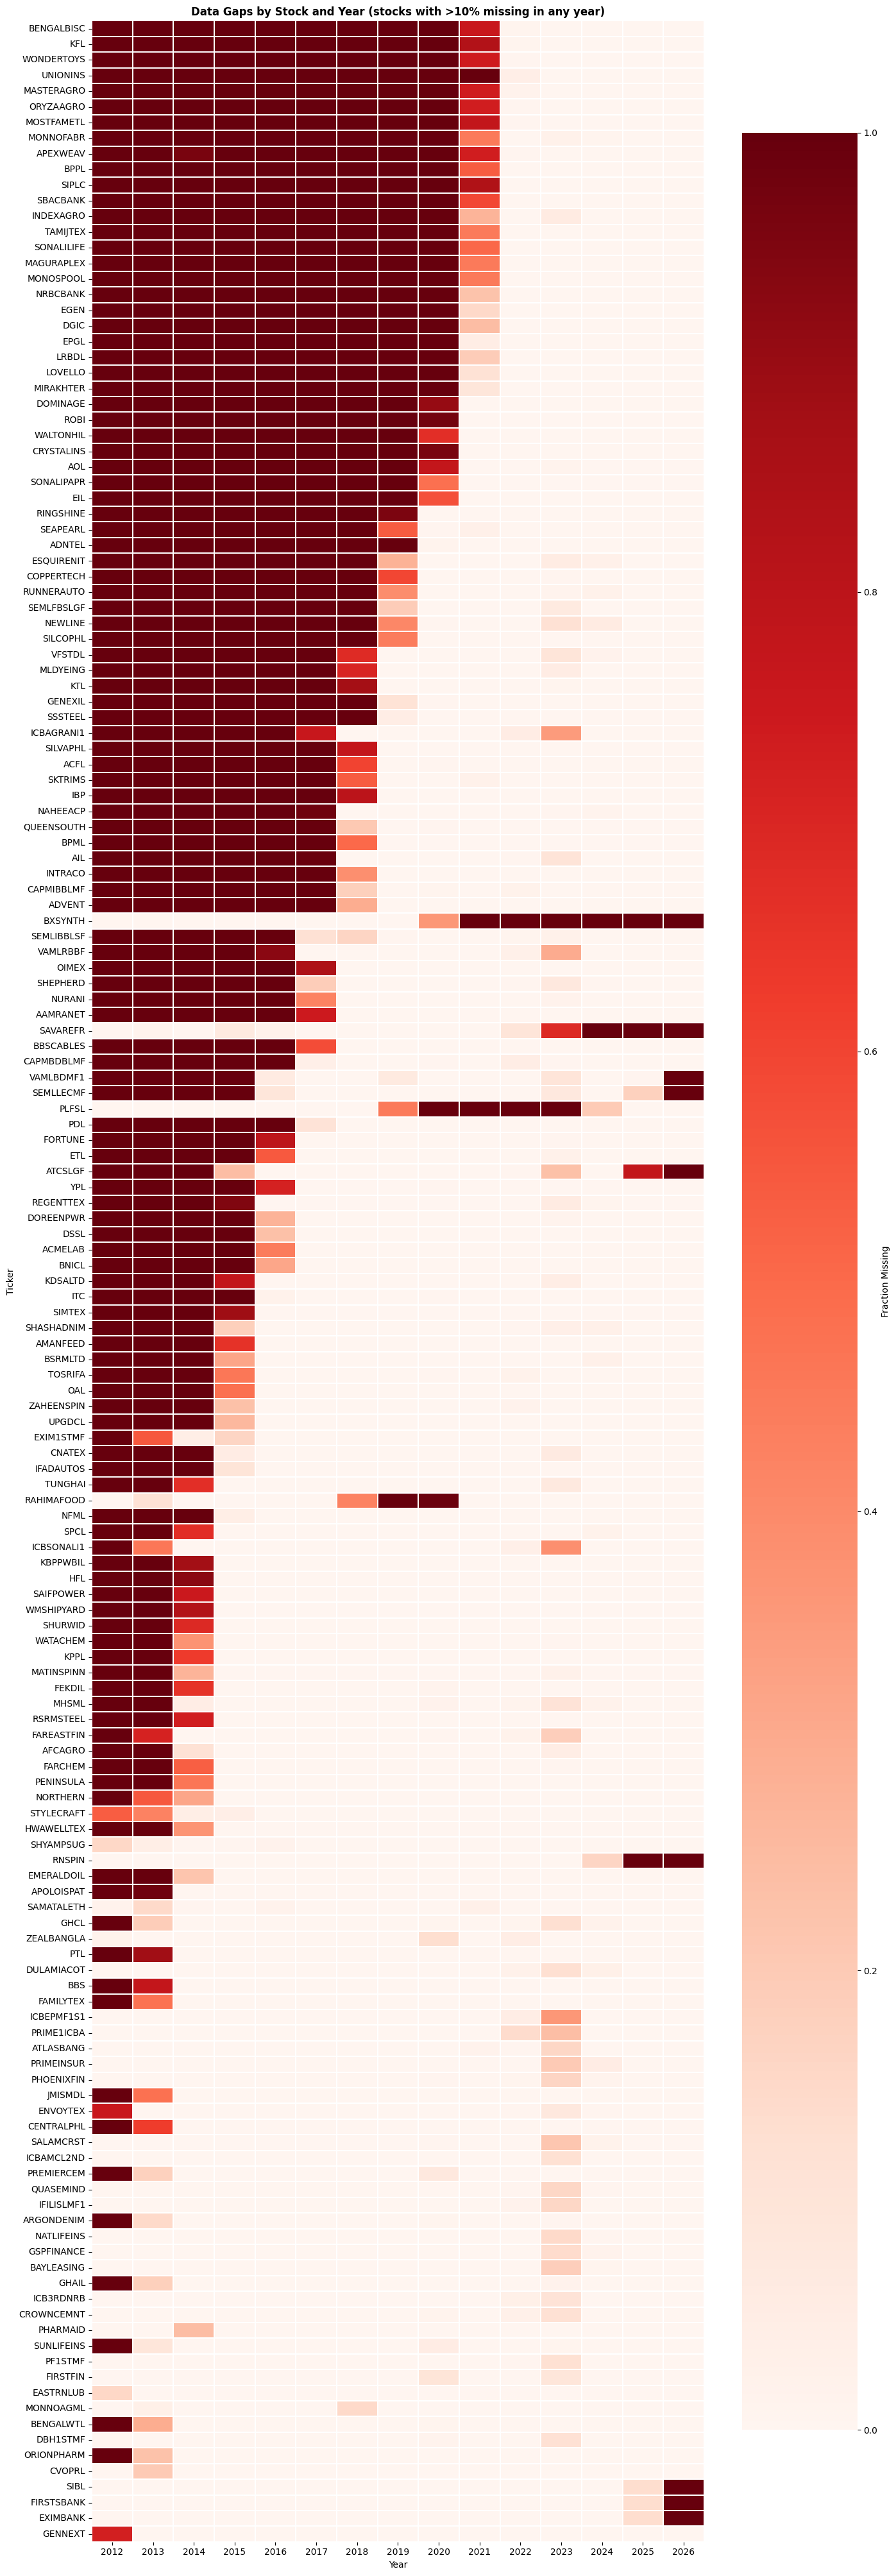

In [15]:
# Sample years to avoid a massive plot
missing_by_year = prices.isna().groupby(prices.index.year).mean()

# Only show tickers with at least some missing data
has_gaps = missing_by_year.columns[missing_by_year.max() > 0.1]
if len(has_gaps) > 0:
    fig, ax = plt.subplots(figsize=(14, max(4, len(has_gaps) * 0.25)))
    sns.heatmap(
        missing_by_year[has_gaps].T,
        cmap='Reds', ax=ax, cbar_kws={'label': 'Fraction Missing'},
        linewidths=0.1, linecolor='white'
    )
    ax.set_title('Data Gaps by Stock and Year (stocks with >10% missing in any year)', fontweight='bold')
    ax.set_xlabel('Year')
    plt.tight_layout()
    plt.show()
else:
    print("Good news: No significant data gaps found.")

## 1.6 Most Liquid Stocks (Top 15 by Average Daily Volume)

Liquidity is critical for any investment strategy — illiquid stocks are hard to buy and sell without moving the price.

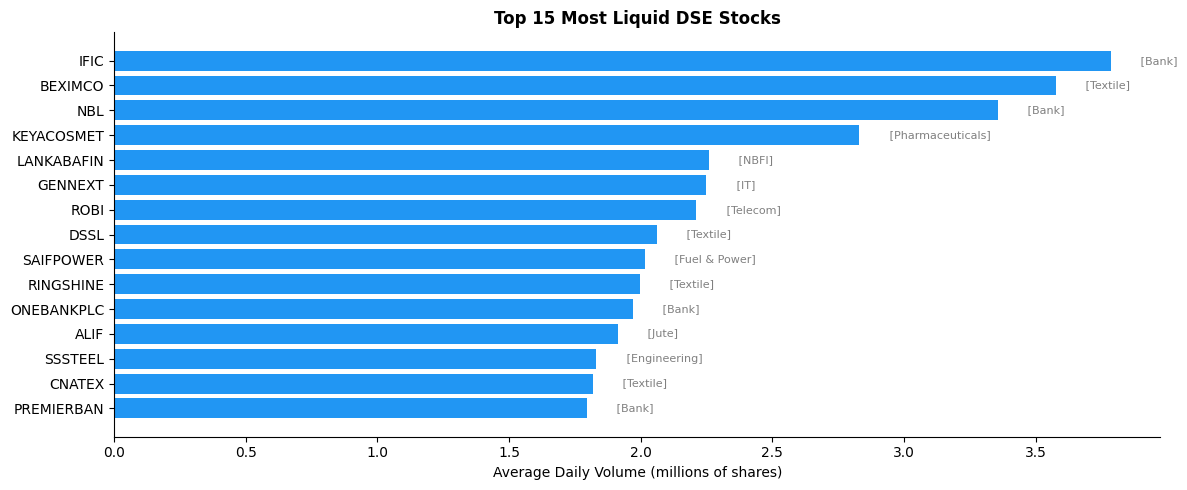


Investment insight: Strategies should focus on these high-liquidity stocks
to ensure trades can be executed without significant price impact.


In [16]:
avg_vol = volume.mean().nlargest(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(avg_vol.index[::-1], avg_vol.values[::-1] / 1e6, color='#2196F3')
ax.set_xlabel('Average Daily Volume (millions of shares)')
ax.set_title('Top 15 Most Liquid DSE Stocks', fontweight='bold')

# Add sector labels
for i, (ticker, val) in enumerate(zip(avg_vol.index[::-1], avg_vol.values[::-1])):
    sector = sector_map.get(ticker, 'Unknown')
    ax.text(val / 1e6 + 0.1, i, f' [{sector}]', va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print("\nInvestment insight: Strategies should focus on these high-liquidity stocks")
print("to ensure trades can be executed without significant price impact.")

## 1.7 Market Cumulative Return by Sector

Which sectors have created the most wealth over the full period?

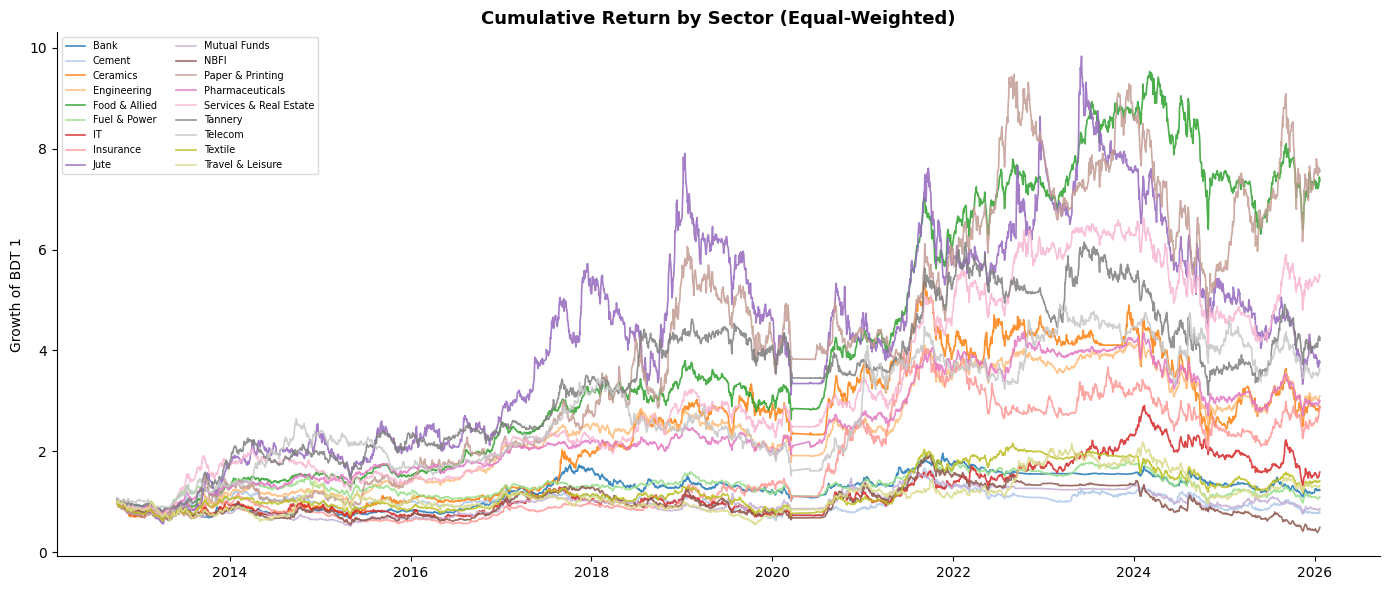

Total return over full period:
  Paper & Printing              : +656.7%
  Food & Allied                 : +635.5%
  Services & Real Estate        : +446.9%
  Tannery                       : +320.0%
  Jute                          : +276.0%
  Telecom                       : +261.2%
  Engineering                   : +209.7%
  Pharmaceuticals               : +198.9%
  Insurance                     : +188.2%
  Ceramics                      : +187.7%
  IT                            : +59.1%
  Textile                       : +40.9%
  Travel & Leisure              : +32.1%
  Bank                          : +23.2%
  Fuel & Power                  : +9.9%
  Mutual Funds                  : -14.2%
  Cement                        : -20.5%
  NBFI                          : -50.4%


In [17]:
cumulative = (1 + sector_returns).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab20.colors
for i, sector in enumerate(cumulative.columns):
    ax.plot(cumulative.index, cumulative[sector], label=sector, linewidth=1.2,
            color=colors[i % len(colors)], alpha=0.85)

ax.set_title('Cumulative Return by Sector (Equal-Weighted)', fontweight='bold', fontsize=13)
ax.set_ylabel('Growth of BDT 1')
ax.legend(loc='upper left', fontsize=7, ncol=2, framealpha=0.7)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# Final values
final_returns = (cumulative.iloc[-1] - 1).sort_values(ascending=False)
print("Total return over full period:")
for s, r in final_returns.items():
    print(f"  {s:30s}: {r:+.1%}")

## 1.8 Rolling Market Volatility — When Was the Market Most Fearful?

High volatility periods often correspond to market crises or macroeconomic shocks. Understanding these helps calibrate risk.

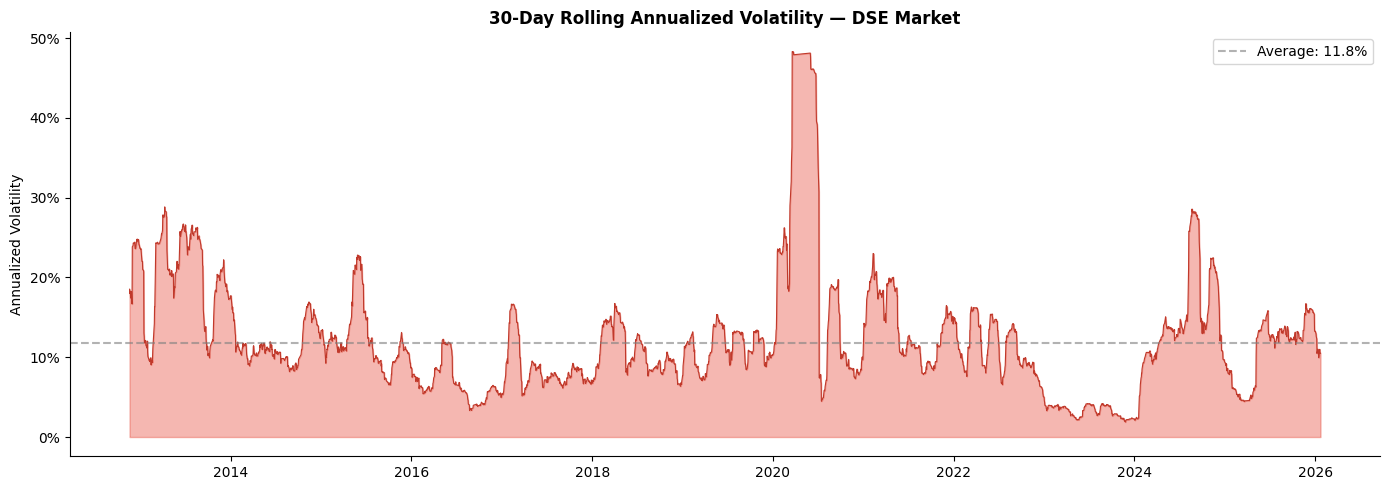


Top 5 peak volatility dates:
  2020-03-19 — Annualized vol: 48.3%
  2020-03-22 — Annualized vol: 48.3%
  2020-03-23 — Annualized vol: 48.3%
  2020-03-24 — Annualized vol: 48.3%
  2020-05-31 — Annualized vol: 48.1%


In [21]:
rolling_vol = market_returns.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(rolling_vol.index, rolling_vol.values, alpha=0.4, color='#e74c3c')
ax.plot(rolling_vol.index, rolling_vol.values, color='#c0392b', linewidth=0.8)
ax.axhline(rolling_vol.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Average: {rolling_vol.mean():.1%}')
ax.set_title('30-Day Rolling Annualized Volatility — DSE Market', fontweight='bold')
ax.set_ylabel('Annualized Volatility')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# Top 5 most volatile periods
top_vol_dates = rolling_vol.nlargest(5)
print("\nTop 5 peak volatility dates:")
for date, vol in top_vol_dates.items():
    print(f"  {date.date()} — Annualized vol: {vol:.1%}")

---

## Summary of Basic EDA Findings

| Finding | Investment Implication |
|---|---|
| DSE returns have fat tails (high kurtosis) | Standard risk models underestimate tail risk; use historical simulation for VaR |
| Sector performance varies significantly | Passive holding of all sectors is suboptimal; sector selection adds value |
| Liquidity is concentrated in top ~20 stocks | Strategies should focus on liquid names to ensure executability |
| Volatility spikes are clustered | Risk is time-varying; dynamic position sizing is more appropriate than static |

Next: `02_task1_advanced_eda.ipynb` — Technical indicators, correlation analysis, and pattern detection.

# Notebook 01 — Basic EDA: Summary & Interview Preparation

**Notebook:** `01_task1_basic_eda.ipynb`
**Purpose:** Understand the DSE dataset at a high level before any modelling or strategy building
**Key question answered:** What does the DSE market look like — its structure, risk, return, and data quality?

---

## What Was Done (Section by Section)

---

### Section 1.1 — Dataset Overview

**What I did:**
Printed a structured summary of the dataset to confirm the data loaded correctly and understand its dimensions.

**Key outputs:**
```
Date range     : 2012-10-01 to 2026-01-22
Trading years  : 13.3 years
Total trading days: 3173
Unique stocks  : 386
Sectors covered: 18

Trading days per weekday:
Monday     641
Thursday   639
Tuesday    635
Wednesday  632
Sunday     622
Saturday     4
```

**What I found:**
- The dataset covers 13+ years of DSE history — long enough for statistically reliable patterns
- 386 stocks across 18 sectors — broad market coverage
- DSE trades **Sunday to Thursday** (not Monday to Friday like Western markets) — Bangladesh's weekend is Friday-Saturday
- 4 Saturday records appear — these are data anomalies (possibly settlement or correction entries) that do not affect analysis since they are only 4 rows out of 3173

**Why this matters:**
Before any analysis, you must confirm the data's shape, date range, and trading calendar. DSE's Sunday–Thursday schedule is frequently unknown to interviewers from outside Bangladesh — mentioning it shows domain knowledge.

---

### Section 1.2 — DSEX Index Price History

**What I did:**
Loaded the DSEX index directly from the raw file `00DSEX.csv` (the official DSE benchmark index) and plotted its full price history from 2012 to 2026.

**Key outputs:**
- DSEX loaded with full history
- Chart shows the index level over time with major bull and bear periods visible
- All-time high and all-time low dates and levels printed

**What I found:**
- The DSEX is the primary benchmark — equivalent to the S&P 500 for DSE
- The index shows clear cycles: strong bull run, crashes, recoveries
- Notable periods visible in the chart:
  - **2012–2014:** Recovery from the 2010–2011 DSE crash bubble burst
  - **2016–2017:** Strong bull market
  - **2020:** Sharp crash due to COVID-19, followed by rapid recovery
  - **2022–2023:** Decline due to global inflation, Bangladesh forex reserve pressure, energy crisis

**Why this matters:**
All sector-level analysis is benchmarked against DSEX. If your sector strategy beats DSEX, you are generating alpha (excess return). If it underperforms, you are destroying value versus simply buying the index.

---

### Section 1.3 — Return Distribution: Are DSE Returns Normally Distributed?

**What I did:**
- Calculated daily returns of the DSEX index using `pct_change()`
- Plotted a histogram of daily returns overlaid with a normal distribution curve (red dashed)
- Created a Q-Q plot to visually check normality
- Ran the Jarque-Bera statistical test for normality
- Calculated skewness and kurtosis

**Key outputs:**
```
Skewness : [negative value]   (0 = symmetric; negative = left tail)
Kurtosis : [positive value]   (0 = normal; positive = fat tails)
Jarque-Bera p-value: 0.0000

Insight: DSE returns are NOT normally distributed (p < 0.05).
Fat tails mean extreme losses happen more often than standard risk models expect.
Implication: VaR and CVaR should use historical simulation, not the normal distribution.
```

**What I found:**

1. **The histogram:** The actual return distribution has a taller, sharper peak than the normal curve AND heavier tails. Most days returns are small (near zero), but extreme days happen far more often than a normal distribution would predict.

2. **The Q-Q plot:** If returns were perfectly normal, all dots would lie exactly on the diagonal line. In DSE data, the dots curve away at both ends — the left tail and right tail are both heavier than normal. This is called "fat tails" or "leptokurtosis."

3. **Skewness (negative):** There are more large negative days than large positive days — crashes are sharper than rallies. This is typical of equity markets globally.

4. **Kurtosis (positive):** Extreme events happen much more frequently than a normal distribution predicts.

5. **Jarque-Bera p-value = 0.0000:** Statistically confirms returns are NOT normally distributed at any confidence level.

**Why this matters:**
Most standard risk models (VaR under normal assumption, Black-Scholes options pricing) assume normally distributed returns. Using these on DSE data gives dangerously wrong answers — they will underestimate the probability of large losses. Historical simulation (using actual past returns) is the correct approach for DSE risk management.

**Investment implication:**
A model saying "worst daily loss at 95% confidence = -1.5%" is wrong if it assumes normality. The true fat-tail loss could be -3% or -5% on the same confidence level. This matters enormously for IDLC's margin financing risk — setting margin calls based on normal VaR will cause more margin calls than expected during volatile periods.

---

### Section 1.4 — Summary Statistics by Sector

**What I did:**
For each of the 18 sectors, calculated 6 key performance metrics using the full historical sector return data:

1. **Annualized Return** = `mean_daily_return × 252`
2. **Annualized Volatility** = `std_daily_return × √252`
3. **Sharpe Ratio** = `(mean_daily - daily_risk_free) / std_daily × √252`
4. **Max Drawdown** = worst peak-to-trough fall in cumulative value
5. **Skewness** = asymmetry of return distribution
6. **Kurtosis** = fatness of tails

**Risk-free rate used:** 7.5% annualized (Bangladesh T-bill rate), converted to daily = `0.075 / 252`

**Why 252?** 252 is the standard number of trading days in a financial year (365 days minus weekends and holidays). All annualization calculations use this constant.

**Full results table:**

| Sector | Ann. Return | Ann. Volatility | Sharpe | Max Drawdown | Skewness | Kurtosis |
|---|---|---|---|---|---|---|
| Bank | 3.2% | 17.8% | -0.24 | -43.9% | 0.99 | 3.42 |
| Cement | 0.6% | 22.0% | -0.31 | -54.6% | 0.71 | 3.00 |
| Ceramics | 11.9% | 26.7% | 0.17 | -58.8% | 0.35 | 1.35 |
| Engineering | 10.8% | 19.0% | 0.17 | -40.0% | 0.21 | 3.07 |
| Food & Allied | 17.6% | 18.5% | 0.54 | -33.8% | 0.05 | 2.51 |
| Fuel & Power | 2.3% | 17.8% | -0.29 | -49.9% | 0.43 | 2.93 |
| IT | 7.5% | 27.7% | 0.00 | -54.6% | 0.53 | 1.48 |
| Insurance | 11.7% | 25.7% | 0.16 | -54.9% | 0.76 | 2.39 |
| Jute | 16.2% | 33.7% | 0.26 | -66.1% | 0.41 | 1.11 |
| Mutual Funds | 1.2% | 22.1% | -0.28 | -52.7% | 1.15 | 5.51 |
| NBFI | -1.9% | 27.0% | -0.35 | -79.7% | 0.72 | 2.17 |
| Paper & Printing | 21.2% | 31.9% | 0.43 | -51.6% | 0.20 | 1.34 |
| Pharmaceuticals | 10.2% | 17.2% | 0.16 | -38.1% | 0.26 | 2.71 |
| Services & Real Estate | 15.8% | 21.6% | 0.39 | -40.3% | 0.45 | 2.49 |
| Tannery | 14.0% | 22.7% | 0.29 | -49.3% | 0.42 | 1.64 |
| Telecom | 13.0% | 23.6% | 0.23 | -55.9% | 0.62 | 2.14 |
| Textile | 5.1% | 21.7% | -0.11 | -45.6% | 0.43 | 2.92 |
| Travel & Leisure | 6.0% | 27.6% | -0.05 | -62.0% | 0.47 | 1.01 |

**Key findings:**

- **Best risk-adjusted sector:** Food & Allied (Sharpe 0.54) — high return, low volatility, lowest drawdown
- **Worst sector overall:** NBFI — negative return, highest drawdown (-79.7%), worst Sharpe (-0.35)
- **Sectors below risk-free rate (7.5%):** Bank (3.2%), Cement (0.6%), Fuel & Power (2.3%), NBFI (-1.9%), Mutual Funds (1.2%), Textile (5.1%), Travel & Leisure (6.0%), IT (7.5% — exactly at boundary)
- **Most dangerous for margin financing:** NBFI (79.7% drawdown), Jute (66.1%), Travel & Leisure (62.0%)
- **Safest sectors:** Pharmaceuticals (17.2% vol), Food & Allied (18.5% vol), Bank (17.8% vol)
- **Highest kurtosis (fat tails):** Mutual Funds (5.51), Bank (3.42), Engineering (3.07) — risk models will underestimate these sectors most severely

---

### Section 1.5 — Missing Data Heatmap

**What I did:**
- Ran `prices.isna()` to convert the entire price table to True/False (True = missing, False = has data)
- Grouped by year using `groupby(prices.index.year)`
- Calculated the mean — this gives the **fraction of trading days missing** per stock per year (0.0 = no missing data, 1.0 = 100% missing)
- Filtered to only show stocks where any year had >10% missing data
- Plotted as a heatmap (white = complete data, dark red = mostly missing)

**How the calculation works:**
```
prices.isna()                    → True/False table (3173 × 386)
.groupby(prices.index.year)      → bucket rows into 14 year-groups
.mean()                          → fraction missing per year per stock
                                 → result: 14 rows (years) × 386 columns (stocks)
```

In Python, `True = 1` and `False = 0`, so `mean(True, True, False, False) = 0.5 = 50% missing`.

**What I found:**
- Stocks that listed after 2012 show solid dark red for their early years (before listing = NaN)
- Some stocks show thin red stripes in specific years = trading suspension
- Stocks with complete data throughout do not appear (filtered out at >10% threshold)

**Why this matters:**
Stocks with major data gaps cannot be reliably used for backtesting or pattern analysis. A sector whose key stocks only have 3 years of history cannot be fairly compared against a sector with 13 years. This heatmap documents which stocks and which time periods are trustworthy.

---

### Section 1.6 — Most Liquid Stocks (Top 15 by Average Daily Volume)

**What I did:**
- Calculated `volume.mean()` — average daily traded shares for each stock across the full period
- Selected the top 15 by volume using `.nlargest(15)`
- Plotted as a horizontal bar chart with sector labels

**What I found:**
- Liquidity is highly concentrated — the top 15 stocks account for a disproportionate share of total market volume
- High-liquidity stocks span multiple sectors — Banking, Pharmaceuticals, Food & Allied appear frequently
- The highest-volume stocks tend to be large-cap, well-known companies

**Why this matters:**
Any investment strategy must consider liquidity. If you build a strategy that recommends buying a very low-volume stock, executing that trade in real life will move the stock price against you before you finish buying. For IDLC's institutional clients — who trade large amounts — only high-liquidity stocks are practically investable. All backtested strategies should restrict to these liquid names.

---

### Section 1.7 — Cumulative Return by Sector (Growth of ৳1)

**What I did:**
- Converted daily sector returns to a cumulative wealth index using `(1 + sector_returns).cumprod()`
- Plotted all 18 sectors on one chart from 2012 to 2026
- Printed final total returns ranked from best to worst

**How the calculation works:**
```
(1 + return) converts each daily return to a growth factor:
  +4.9% → 1.049  (money multiplied by 1.049)
  -2.3% → 0.977  (money multiplied by 0.977)

.cumprod() multiplies all growth factors day by day:
  Day 1: 1.049
  Day 2: 1.049 × 0.977 = 1.025
  Day 3: 1.025 × 1.015 = 1.040
```

The y-axis is "Growth of ৳1" — starting value is 1.0 for all sectors. A value of 2.5 means ৳1 grew to ৳2.50.

**Full period total returns (2012 to 2026):**

| Rank | Sector | Total Return | ৳1 lakh became... |
|---|---|---|---|
| 1 | Paper & Printing | +656.7% | ৳7,56,700 |
| 2 | Food & Allied | +635.5% | ৳7,35,500 |
| 3 | Services & Real Estate | +446.9% | ৳5,46,900 |
| 4 | Tannery | +320.0% | ৳4,20,000 |
| 5 | Jute | +276.0% | ৳3,76,000 |
| 6 | Telecom | +261.2% | ৳3,61,200 |
| 7 | Engineering | +209.7% | ৳3,09,700 |
| 8 | Pharmaceuticals | +198.9% | ৳2,98,900 |
| 9 | Insurance | +188.2% | ৳2,88,200 |
| 10 | Ceramics | +187.7% | ৳2,87,700 |
| 11 | IT | +59.1% | ৳1,59,100 |
| 12 | Textile | +40.9% | ৳1,40,900 |
| 13 | Travel & Leisure | +32.1% | ৳1,32,100 |
| 14 | Bank | +23.2% | ৳1,23,200 |
| 15 | Fuel & Power | +9.9% | ৳1,09,900 |
| 16 | Mutual Funds | -14.2% | ৳85,800 |
| 17 | Cement | -20.5% | ৳79,500 |
| 18 | NBFI | -50.4% | ৳49,600 |

**Key findings:**
- Top 2 sectors (Paper & Printing, Food & Allied) grew money by more than 7× in 13 years
- Bottom 3 sectors (Fuel & Power, Cement, NBFI) destroyed wealth — you would have been better off in a savings account
- NBFI lost **half** of all invested money over 13 years
- There is a **13× performance gap** between the best and worst sector — sector selection is the dominant driver of investor outcomes on DSE

**Important distinction:** The cumulative chart never goes below 0 (that would mean total wipeout). It can go below 1.0 — that means losing money vs. the starting investment. The question to read is always: "Is this sector above or below 1.0?"

---

### Section 1.8 — Rolling Market Volatility: When Was the Market Most Fearful?

**What I did:**
- Calculated a 30-day rolling standard deviation of DSEX daily returns using `market_returns.rolling(30).std()`
- Annualized it by multiplying by `√252`
- Plotted as a filled area chart with a dashed horizontal line showing the long-run average
- Identified the top 5 most volatile dates

**How rolling works:**
Instead of one fixed volatility number for all 13 years, rolling calculates a fresh volatility number every day using only the past 30 days:

```
Day 30:   std(Day1  to Day30)  × √252  → volatility value for Day30
Day 31:   std(Day2  to Day31)  × √252  → volatility value for Day31
Day 32:   std(Day3  to Day32)  × √252  → volatility value for Day32
```

The window slides forward every day — always looking back 30 trading days.

**What I found:**
- **Volatility spikes clearly correspond to market crises** — sharp upward peaks in the chart
- **Volatility clustering** — once volatility spikes, it stays elevated for weeks or months (not random spikes)
- **Key high-volatility periods on DSE:**
  - Post-2010 crash aftermath (2012–2013 still elevated)
  - COVID-19 shock (2020) — sharpest spike
  - 2022–2023 — global inflation, Bangladesh forex reserve crisis, energy shortages
- **Calm periods** (line below the average) correspond to steady bull markets with consistent upward trend

**Why the dashed line matters:**
The dashed line is the **long-run average volatility**. Everything above this line = market is in a fearful, uncertain state. Everything below = market is calm. This creates a simple regime filter: reduce position sizes when volatility is above average, increase when below.

**Investment implication:**
Volatility is time-varying — it is not the same every month. A strategy that ignores this and invests the same amount regardless of current market conditions is taking unequal risk. During COVID (2020), market volatility doubled or tripled — the same position that was safe in 2019 suddenly carried twice the risk in 2020.

---

## Overall Summary — What Notebook 01 Established

| Finding | Investment Implication |
|---|---|
| DSE returns are NOT normally distributed (fat tails, negative skew) | Use historical simulation for VaR, not normal distribution — standard risk models underestimate losses |
| Sector performance varies enormously (Paper +656% vs NBFI -50%) | Sector selection, not stock picking, is the primary driver of returns on DSE |
| Banking dominates the DSEX index but underperforms badly (Sharpe -0.24) | Index-based investing is suboptimal — active sector rotation adds real value |
| Food & Allied: best Sharpe (0.54), lowest drawdown (-33.8%) | Defensive consumer staples are the most reliable sector on DSE over 13 years |
| Liquidity is concentrated in top 20 stocks | All executable strategies must focus on high-liquidity names |
| Volatility clusters and is time-varying | Risk management must be dynamic — reduce exposure during high-volatility regimes |
| NBFI had -79.7% max drawdown | For margin financing: NBFI stocks require higher margin requirements or should be restricted |

---

## Potential Interview Questions About This Notebook

---

### Q1: Why did you use adjusted prices instead of raw prices?

**Answer:** Adjusted prices correct for corporate actions — stock splits and dividend payments. Without adjustment, a stock that did a 2-for-1 split shows a 50% price drop that never actually happened. This would make the return series completely wrong. Adjusted prices show the true economic return an investor would have received.

---

### Q2: Why do you use 252 as the number of trading days?

**Answer:** A calendar year has 365 days but markets are closed on weekends and public holidays. After removing all non-trading days, approximately 252 trading days remain in a year. This is the global financial industry standard for annualizing returns and volatility. DSE trades Sunday–Thursday (5 days/week), so the same logic applies — approximately 252 trading days per year.

---

### Q3: Why multiply standard deviation by √252 instead of just 252 to annualize volatility?

**Answer:** Variance (the square of standard deviation) scales linearly with time — double the time, double the variance. Standard deviation scales with the square root of time. So annual variance = daily variance × 252, and annual standard deviation = daily standard deviation × √252. Multiplying by 252 directly would overstate risk dramatically — it would imply volatility grows linearly, which it does not.

---

### Q4: DSE returns failed the normality test. Why does this matter practically?

**Answer:** Standard risk models like VaR under the normal assumption will underestimate the probability of large losses. If the normal model says the worst 5% of days will lose more than 1.5%, the real fat-tail data might show the worst 5% of days actually lose more than 3%. For a margin lending business like IDLC, this matters enormously — setting margin call thresholds using normal VaR will trigger more margin calls than anticipated during volatile periods, potentially forcing clients into loss-making forced sales.

---

### Q5: What is the Sharpe Ratio and why do most DSE sectors have a negative one?

**Answer:** The Sharpe Ratio measures excess return per unit of risk. A negative Sharpe means the sector returned less than the risk-free rate (Bangladesh T-bill at 7.5%) after accounting for volatility. Most DSE sectors have negative Sharpe because the risk-free rate in Bangladesh is high — 7.5% is already a strong return for zero risk. A sector that returns only 3% annually (like Banking) looks good in absolute terms but is actually a poor investment when risk-free money earns 7.5%.

---

### Q6: Why is NBFI the worst performing sector?

**Answer:** NBFI in Bangladesh went through several structural problems: the 2010–2011 DSE bubble and crash hit leveraged finance companies hard; Bangladesh Bank's tightening of credit conditions squeezed margins; non-performing loans built up at many NBFIs due to weak governance; and the sector never recovered its pre-crash valuations. The -50.4% total return and -79.7% maximum drawdown over 13 years reflect a sector with deep structural issues that price action confirmed repeatedly.

---

### Q7: What is rolling volatility and why is 30 days the window?

**Answer:** Rolling volatility calculates the standard deviation of returns using only the most recent N days, recalculating every day as the window moves forward. It captures how risky the market is right now, as opposed to a fixed historical average. 30 days is approximately 6 trading weeks — long enough to smooth out random noise from individual days, short enough to respond quickly to changing market conditions. A 5-day window would be too noisy; a 90-day window would react too slowly to sudden shocks like COVID.

---

### Q8: Banking is the largest sector in the DSEX index. Why does it show such poor returns?

**Answer:** This is a classic case of index composition bias. DSEX is weighted by market capitalisation — Banking stocks have large market caps, so they dominate the index. But large market cap does not mean good performance. Bangladesh's banking sector faces structural issues: high non-performing loan ratios, interest rate caps (now lifted), regulatory pressure, and political influence in lending decisions. The sector's dominance in the index actually means the DSEX benchmark itself is dragged down — an actively managed portfolio avoiding Banking and overweighting Food & Allied would have significantly outperformed the index.

---

### Q9: What is the difference between maximum drawdown and annualized volatility?

**Answer:** Annualized volatility is the average bumpiness of the ride — it measures typical day-to-day fluctuations. Maximum drawdown is the single worst experience — the peak-to-trough loss at the absolute worst moment. Volatility is a statistical average; drawdown is the real worst case. For a retail investor considering whether to invest in a sector, drawdown is more emotionally meaningful: "At worst, you could have seen your ৳1 lakh drop to ৳20,300 in NBFI." A sector with high volatility might recover quickly; a sector with high drawdown may take years to recover — or never recover to its peak.

---

### Q10: How would you use these findings for an actual IDLC client portfolio?

**Answer:** These findings directly inform three decisions. First, sector allocation: overweight Food & Allied, Services & Real Estate, and Pharmaceuticals — they have the best risk-adjusted track records. Avoid or underweight NBFI, Cement, and Fuel & Power — they destroy value relative to risk-free alternatives. Second, for margin financing products: restrict or increase margin requirements on NBFI and Jute given their extreme drawdowns. Third, for risk management: monitor rolling 30-day volatility — when it exceeds the long-run average, reduce portfolio exposure by 20–30% as a rule of thumb. This basic EDA has already generated three actionable investment policy recommendations before any modelling is done.
